# Tutorial IV: Who gets access? Equity of accessibility in Munich

## Getting started

There are three options to run the codes in this tutorial:

1. Copy-paste the codes from the website and run them line by line on your own computer with your preferred IDE (JupyterLab, Spyder, PyCharm, etc.).
2. Download this Notebook (see below) and run it in JupyterLab, which you have installed by following the [installation instructions](https://sumogis.readthedocs.io/en/latest/course-info/installing-miniconda.html).
3. Run the codes in Binder (see below). This needs no installation, but Binder has very limited computational resources, and the analyses in this tutorial need more memory than Binder offers.

### Download the Notebook

You can download this tutorial Notebook to your own computer by clicking the **Download button** from the menu on the top-right section of the website.

- Right-click the option that says `.ipynb` and choose **"Save link as .."**

![Download tutorial Notebook.](../img/Download_notebook_button.png)

### Run the codes on your own computer

Before you can run this Notebook, you need to launch the JupyterLab programming environment, which comes with the course environment (if you have not installed it yet, follow the [installation instructions](https://sumogis.readthedocs.io/en/latest/course-info/installing-miniconda.html)). To run JupyterLab:

1. Using the terminal or command prompt, change to the folder where you downloaded the Notebook: `$ cd /mydirectory/`
2. Activate the course environment: `$ conda activate sumogis`
3. Launch JupyterLab: `$ jupyter lab`

After these steps, the JupyterLab interface opens in your browser, and you can start executing cells (see the hints below at "Working with Jupyter Notebooks").

#### Alternatively: Run codes in Binder (with limited resources)

You can also run this Notebook by launching a Binder instance from the buttons at the top-right of this page, which look like this:

![Launch Binder](../img/launch_binder.png)

Building the routable networks of this tutorial takes roughly 5 GB of memory, so expect the larger examples to fail in Binder. We recommend running the Notebook on your own computer.

### Working with Jupyter Notebooks

Jupyter Notebooks are documents that combine computer code with rich text elements (such as text, figures, tables and links), and you run them inside the JupyterLab programming environment.

**A couple of hints**:

- You can **execute a cell** by clicking a given cell that you want to run and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd> (or by clicking the "Play" button on top).
- You can **change the cell type** between `Markdown` (for writing text) and `Code` (for writing and executing code) from the dropdown menu above.

See **further details and help for** [**using Notebooks and JupyterLab from here**](https://pythongis.org/part1/chapter-01/nb/04-using-jupyterlab.html).

## Introduction

In [Tutorial II](../L2/cafein_tutorial.ipynb) and [Tutorial III](../L2/cafein_munich.ipynb), we calculated how long it takes to reach places and how much emissions the trips cause. An **equity analysis** goes one step further and asks how accessibility is distributed across people and places. Do some residents have much better access than others? Do children and older residents have the same access as everyone else? Is access concentrated in the more expensive neighborhoods? How many people fall below a minimum level of access, and where do several disadvantages overlap?

These questions look at access from two angles. The first is **distribution**: how unequally access is shared between people. The second is **sufficiency**: whether everyone reaches a minimum level of access that they need in their daily life. A city can have a fairly equal distribution while many residents still fall below the minimum, and the other way round. Willberg et al. (2024) bring these ideas together as [just accessibility within planetary boundaries](https://doi.org/10.1080/01441647.2023.2240958): access that is sufficient and fairly shared, and that stays within environmental limits.

`cafein` includes a set of equity measures in its `cafein.equity` module, and the results of `cafein.Accessibility` have shortcuts to them. In this tutorial, we use them to study the access to four everyday services by public transport in Munich: supermarkets, pharmacies, doctors and schools. As socio-economic data, we use the results of the 2022 German census, which are published on a grid of 1 km squares.

Let's start by importing the libraries that we use in this tutorial:

In [1]:
import datetime
import urllib.request
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pyrosm

import cafein
from cafein import equity

## Data

### Munich data package

We continue with the data package of Tutorial III, which contains the study area (the City of Munich and the Landkreis München), the OpenStreetMap data and the public transport schedules.

**[Download the Munich data package](https://drive.google.com/file/d/16DxOAK17ICc7mEHfUAqOEZu_3z8M9LTd/view?usp=sharing)** (118 MB) if you have not done so already, and extract it into a folder called `data` next to this Notebook. The ZIP file contains a folder called `munich`, so the files end up in `data/munich`. Let's define the paths to the files:

In [2]:
# Folder of the data package
munich_dir = Path("../L2/data/munich")

# Paths to the files in it
gtfs_fp = munich_dir / "munich_delfi_gtfs.zip"
osm_fp = munich_dir / "munich_osm.pbf"
study_area_fp = munich_dir / "munich_study_area.gpkg"

### Census data

The statistical offices of Germany publish the results of the [2022 census](https://www.destatis.de/DE/Themen/Gesellschaft-Umwelt/Bevoelkerung/Zensus2022/_inhalt.html) (*Zensus 2022*, reference date 15 May 2022) on grids of 100 m, 1 km and 10 km squares. The grids follow the European INSPIRE standard and use the ETRS89-LAEA Europe projection (EPSG:3035). The data are licensed under the [Data licence Germany – attribution – version 2.0](https://www.govdata.de/dl-de/by-2-0).

We download two tables, each as a ZIP file that contains a CSV file for each grid size:

- **Age in five age classes**: the number of residents in each grid square, in total and by age class (32 MB).
- **Average net rent**: the average rent per square meter of the rented dwellings in each grid square, without heating and other utilities (*Nettokaltmiete*, 9 MB).

In [3]:
# Folder for the census data
census_dir = Path("data/census")
census_dir.mkdir(parents=True, exist_ok=True)

# Address of the census grid data
census_url = "https://www.destatis.de/static/DE/zensus/gitterdaten"

# Paths to the two ZIP files
ages_zip = census_dir / "Alter_in_5_Altersklassen.zip"
rents_zip = census_dir / "Zensus2022_Durchschn_Nettokaltmiete.zip"

# Download the files (only once)
if not ages_zip.exists():
    urllib.request.urlretrieve(f"{census_url}/{ages_zip.name}", ages_zip)

if not rents_zip.exists():
    urllib.request.urlretrieve(f"{census_url}/{rents_zip.name}", rents_zip)

Now we can read the CSV files of the 1 km grid directly from the ZIP files with `pandas`. The files use semicolons as separators, and the rent file uses a comma as the decimal separator. A dash (`–`) in the age table means that the value is zero or has been set to zero to protect the privacy of the residents, so we read it as a missing value and replace it with zero:

In [4]:
# Read the age table of the 1 km grid
with zipfile.ZipFile(ages_zip) as z:
    with z.open("Alter_in_5_Altersklassen/Zensus2022_Alter_in_5_Altersklassen_1km-Gitter.csv") as f:
        ages = pd.read_csv(f, sep=";", na_values="–")

# Read the rent table of the 1 km grid
with zipfile.ZipFile(rents_zip) as z:
    with z.open("Zensus2022_Durchschn_Nettokaltmiete_1km-Gitter.csv") as f:
        rents = pd.read_csv(f, sep=";", decimal=",")

ages.head()

,GITTER_ID_1km,x_mp_1km,y_mp_1km,Insgesamt_Bevoelkerung,Unter18,a18bis29,a30bis49,a50bis64,a65undaelter
0,CRS3035RES1000mN2689000E4337000,4337500,2689500,4,NaN,NaN,NaN,NaN,NaN
1,CRS3035RES1000mN2689000E4341000,4341500,2689500,11,NaN,NaN,NaN,NaN,NaN
2,CRS3035RES1000mN2690000E4341000,4341500,2690500,4,NaN,NaN,NaN,NaN,NaN
3,CRS3035RES1000mN2691000E4340000,4340500,2691500,3,NaN,NaN,NaN,NaN,NaN
4,CRS3035RES1000mN2691000E4341000,4341500,2691500,22,3.0,7.0,5.0,5.0,3.0


Each row is one grid square, identified by `GITTER_ID_1km`, and `x_mp_1km` and `y_mp_1km` give the coordinates of its center in EPSG:3035. Of the age classes, we keep the total population, the residents under 18 years (our **children**) and the residents aged 65 or older (our **older residents**). From the rent table, we keep the average rent (`durchschnMieteQM`). Let's give the columns shorter English names and join the two tables:

In [5]:
# Keep and rename the columns of the age table
ages = ages.rename(columns={
    "GITTER_ID_1km": "id",
    "Insgesamt_Bevoelkerung": "population",
    "Unter18": "children",
    "a65undaelter": "older",
})
ages = ages[["id", "x_mp_1km", "y_mp_1km", "population", "children", "older"]]

# Replace the missing values (dashes) with zeros
ages[["children", "older"]] = ages[["children", "older"]].fillna(0)

# Keep and rename the columns of the rent table
rents = rents.rename(columns={"GITTER_ID_1km": "id", "durchschnMieteQM": "rent"})
rents = rents[["id", "rent"]]

# Join the rents to the age table (squares without rented dwellings get no rent)
census = ages.merge(rents, on="id", how="left")

census.head()

,id,x_mp_1km,y_mp_1km,population,children,older,rent
0,CRS3035RES1000mN2689000E4337000,4337500,2689500,4,0.0,0.0,NaN
1,CRS3035RES1000mN2689000E4341000,4341500,2689500,11,0.0,0.0,NaN
2,CRS3035RES1000mN2690000E4341000,4341500,2690500,4,0.0,0.0,NaN
3,CRS3035RES1000mN2691000E4340000,4340500,2691500,3,0.0,0.0,NaN
4,CRS3035RES1000mN2691000E4341000,4341500,2691500,22,3.0,3.0,6.26


The census tables give only the center point of each square. Let's turn them into squares of 1 × 1 km by drawing a square buffer of 500 m around each center point, and select the squares that intersect our study area with a spatial join:

In [6]:
# Center points of the grid squares
centers = gpd.points_from_xy(census["x_mp_1km"], census["y_mp_1km"])

# Squares of 1 x 1 km around the center points
squares = centers.buffer(500, cap_style="square")

# Create a GeoDataFrame of the grid
grid = gpd.GeoDataFrame(census.drop(columns=["x_mp_1km", "y_mp_1km"]), geometry=squares, crs="EPSG:3035")

# Read the study area in the same CRS
study_area = gpd.read_file(study_area_fp).to_crs(grid.crs)

# Select the squares that intersect the study area
cells = gpd.sjoin(grid, study_area[["geometry"]], predicate="intersects")
cells = cells.drop(columns="index_right")

cells.head()

,id,population,children,older,rent,geometry
9612,CRS3035RES1000mN2757000E4443000,9,4.0,0.0,NaN,"POLYGON ((4444000 2758000, 4444000 2757000, 44..."
9613,CRS3035RES1000mN2757000E4444000,78,10.0,13.0,10.29,"POLYGON ((4445000 2758000, 4445000 2757000, 44..."
9614,CRS3035RES1000mN2757000E4445000,11,3.0,0.0,12.34,"POLYGON ((4446000 2758000, 4446000 2757000, 44..."
9617,CRS3035RES1000mN2757000E4450000,3,0.0,3.0,NaN,"POLYGON ((4451000 2758000, 4451000 2757000, 44..."
9878,CRS3035RES1000mN2758000E4442000,9,4.0,0.0,14.19,"POLYGON ((4443000 2759000, 4443000 2758000, 44..."


In [7]:
print(f"Number of grid squares: {len(cells)}")
print(f"Residents: {cells['population'].sum():,.0f}")
print(f"Children (under 18): {cells['children'].sum():,.0f}")
print(f"Older residents (65+): {cells['older'].sum():,.0f}")

Number of grid squares: 763
Residents: 1,869,560
Children (under 18): 307,995
Older residents (65+): 337,559


The census only lists the squares where people live, so our grid has no empty squares. Let's map the number of residents, the share of older residents (in the squares with at least 100 residents) and the average rent:

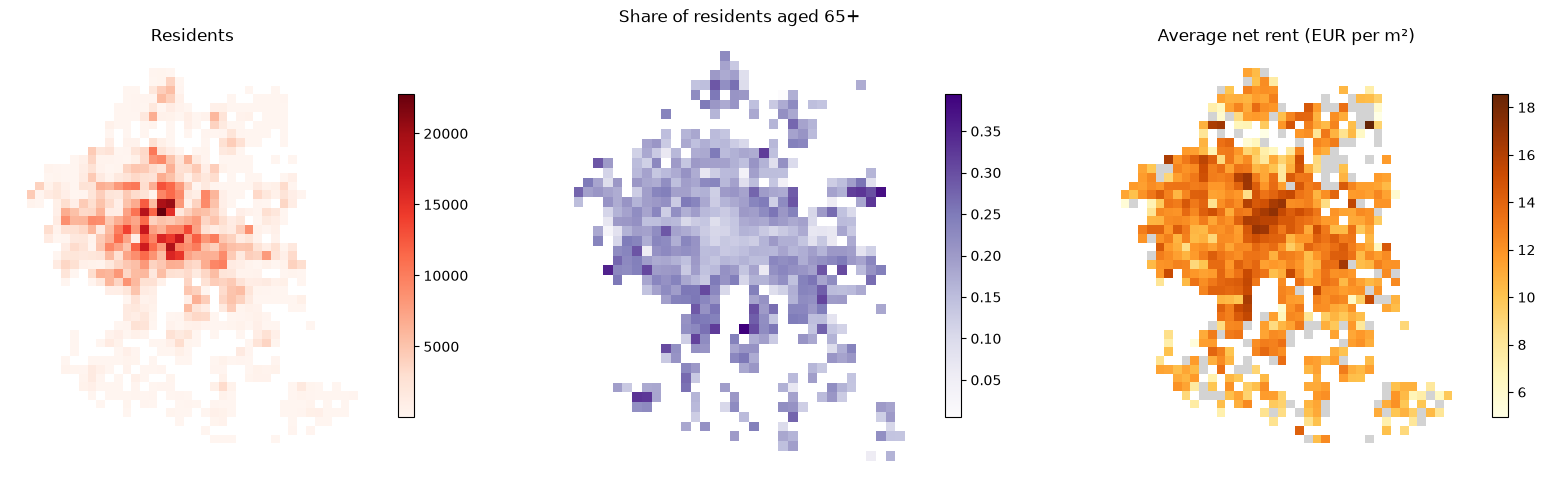

In [8]:
# Calculate the share of older residents in each square
cells["older_share"] = cells["older"] / cells["population"]

# Squares with only a few residents can have extreme shares, so we map the share only for squares with at least 100 residents
populated = cells.loc[cells["population"] >= 100]

# Create a figure with three maps side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Plot the number of residents
cells.plot(ax=ax1, column="population", cmap="Reds", legend=True, legend_kwds={"shrink": 0.7})
ax1.set_title("Residents")
ax1.set_axis_off()

# Plot the share of older residents
populated.plot(ax=ax2, column="older_share", cmap="Purples", legend=True, legend_kwds={"shrink": 0.7})
ax2.set_title("Share of residents aged 65+")
ax2.set_axis_off()

# Plot the average rent (squares without a rent in grey)
cells.plot(ax=ax3, column="rent", cmap="YlOrBr", legend=True, legend_kwds={"shrink": 0.7}, missing_kwds={"color": "lightgrey"})
ax3.set_title("Average net rent (EUR per m²)")
ax3.set_axis_off()

As we can see, the population is densest in the City of Munich, while the share of older residents is lower in the city center than in many of the outer neighborhoods. The rents are highest in and around the city center and lower towards the edges of the region. The rent is missing in some squares (grey), e.g. where there are no rented dwellings.

### Everyday services from OpenStreetMap

As destinations, we use four everyday services from the OpenStreetMap data: supermarkets, pharmacies, doctors and schools. We extract them with `pyrosm` and use the centroid of each building or area as its location:

In [9]:
# Read the OpenStreetMap data
osm = pyrosm.OSM(str(osm_fp))

# Extract the services
pois = osm.get_pois(custom_filter={"amenity": ["doctors", "pharmacy", "school"], "shop": ["supermarket"]})

# Name the service of each place: supermarkets are tagged as shops, the others as amenities
pois["service"] = pois["amenity"].fillna(pois["shop"])

# Use the centroids as locations (calculated in a metric CRS)
pois = pois.to_crs(cells.crs)
pois["geometry"] = pois.centroid

pois["service"].value_counts()

service
doctors        1378
supermarket     880
school          761
pharmacy        455
Name: count, dtype: int64

`cafein.Accessibility` counts the destinations that can be reached from each origin. With the `opportunities` parameter, we can count several kinds of destinations at once: each column that we name counts the destinations by its values. Let's add one column for each service, with the value 1 for the places of that service and 0 for the others, and give each place a unique `id`:

In [10]:
# The services that we analyze
services = ["supermarket", "pharmacy", "doctors", "school"]

# Add a column of ones and zeros for each service
for service in services:
    pois[service] = (pois["service"] == service).astype(int)

# Create a unique id for each place
pois["id"] = pois["id"].astype(str) + "_" + pois["service"]
pois = pois.drop_duplicates("id")

pois[["id", "service", *services]].head()

,id,service,supermarket,pharmacy,doctors,school
0,26603836_supermarket,supermarket,1,0,0,0
1,27212498_supermarket,supermarket,1,0,0,0
2,71412887_supermarket,supermarket,1,0,0,0
3,71412898_supermarket,supermarket,1,0,0,0
4,71412907_supermarket,supermarket,1,0,0,0


## Accessibility to everyday services

Next, let's build the public transport network in the same way as in Tutorial III:

In [11]:
%%time
# Build the public transport network from the GTFS and OpenStreetMap data
network = cafein.TransportNetwork.from_gtfs(gtfs_fp, osm_pbf=osm_fp)

.../site-packages/cafein/streets.py:374: UserWarning: 7657 stop(s) are farther than 1600.0 m from the walking network and get no footpaths
  snapped = _snap_to_edges(stop_points, edges, max_snap_distance)


CPU times: user 21 s, sys: 1.42 s, total: 22.4 s
Wall time: 20.3 s


As in Tutorial III, we use Tuesday, 6 October 2026, at 8 AM as our departure time. Now we can count the services that can be reached by public transport (including walking) within 15 and 30 minutes from each grid square. `cafein` routes from the center of each square:

In [12]:
%%time
# Departure time: Tuesday 6 October 2026 at 8 AM
departure = datetime.datetime(2026, 10, 6, 8, 0)

# Count the services that can be reached within 15 and 30 minutes
access = cafein.Accessibility(
    network,
    origins=cells[["id", "geometry"]],
    destinations=pois[["id", *services, "geometry"]],
    departure=departure,
    opportunities=services,
    budgets=(15, 30),
)

access.head()

CPU times: user 1min 14s, sys: 317 ms, total: 1min 14s
Wall time: 10.9 s


,from_id,opportunity,budget,accessibility
0,CRS3035RES1000mN2757000E4443000,supermarket,15.0,0.0
1,CRS3035RES1000mN2757000E4443000,pharmacy,15.0,0.0
2,CRS3035RES1000mN2757000E4443000,doctors,15.0,0.0
3,CRS3035RES1000mN2757000E4443000,school,15.0,0.0
4,CRS3035RES1000mN2757000E4443000,supermarket,30.0,0.0


The result is in a long format: one row for each origin (`from_id`), service (`opportunity`) and travel time budget (`budget`), and the `accessibility` column tells how many places of the service can be reached. Let's map the number of each service within 30 minutes:

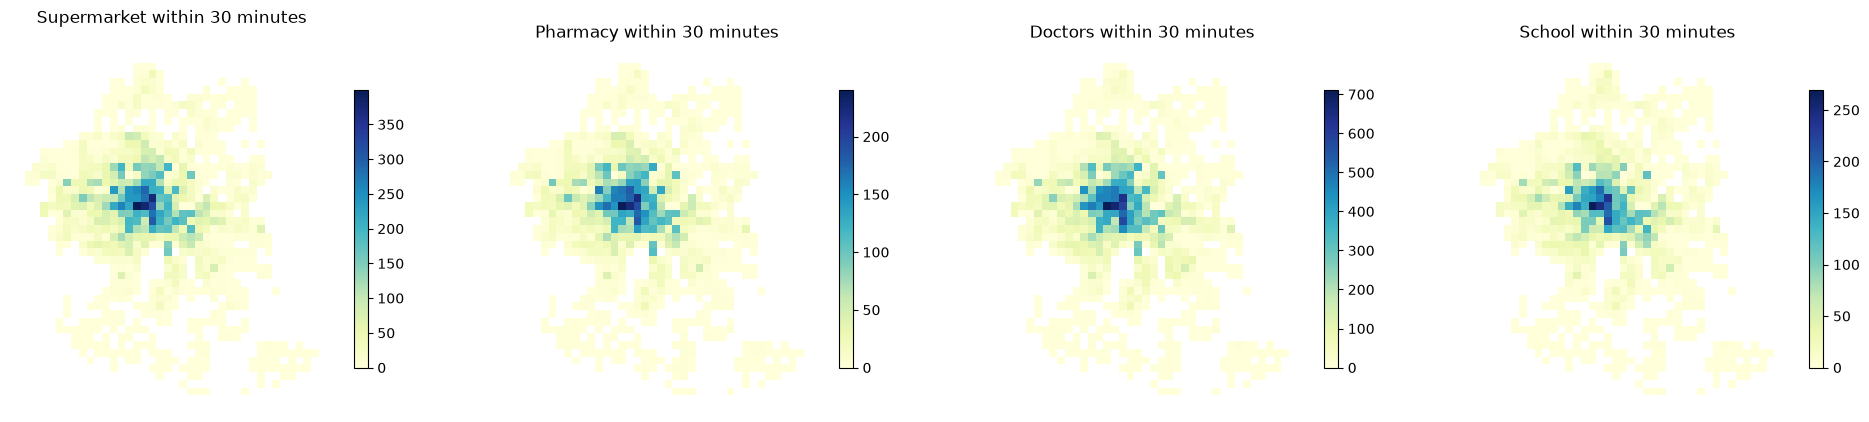

In [13]:
# Select the results for the 30-minute budget
access_30 = access.loc[access["budget"] == 30]

# Join the results to the grid squares
cells_30 = cells.merge(access_30, left_on="id", right_on="from_id")

# Create a figure with four maps
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Plot each service on its own map
for ax, service in zip(axes, services):
    service_cells = cells_30.loc[cells_30["opportunity"] == service]
    service_cells.plot(ax=ax, column="accessibility", cmap="YlGnBu", legend=True, legend_kwds={"shrink": 0.6})
    ax.set_title(f"{service.capitalize()} within 30 minutes")
    ax.set_axis_off()

As we can see, the residents of the city center can reach hundreds of doctors and supermarkets within 30 minutes, while many residents at the edges of the region reach only a few. But how unequal is this distribution, and who is affected? Let's find out.

## How unequally is access distributed?

The **Lorenz curve** and the **Gini index** are classic measures of inequality, and they are often used for income. Here, we sort the residents by their accessibility and ask how large a share of the total accessibility the residents with the poorest access have. If everyone had the same access, the Lorenz curve would be a straight diagonal line and the Gini index would be 0. The more unequal the access, the further the curve bends from the diagonal, and the closer the Gini index gets to 1.

Our grid squares have very different numbers of residents, and we are interested in people, not squares. Therefore, we give each square a weight by its number of residents with the `population` parameter. The census data that we pass with `sociodemographic_data` joins to the accessibility results through the `id` column:

In [14]:
# The census data of each grid square
census_data = cells[["id", "population", "children", "older", "rent"]]

# Calculate the Gini index for each service and budget, weighted by the number of residents
gini = access.gini_index(sociodemographic_data=census_data, population="population")

gini.round(3)

,opportunity,budget,gini_index
0,doctors,15.0,0.617
1,doctors,30.0,0.493
2,pharmacy,15.0,0.615
3,pharmacy,30.0,0.500
4,school,15.0,0.559
5,school,30.0,0.497
6,supermarket,15.0,0.545
7,supermarket,30.0,0.482


The Gini indices are high: between 0.55 and 0.62 within 15 minutes, and around 0.5 within 30 minutes. The access to doctors and pharmacies within 15 minutes is the most unequal. Within 30 minutes, more residents reach at least some places, so the distribution evens out.

Let's also draw the Lorenz curves of the access to doctors:

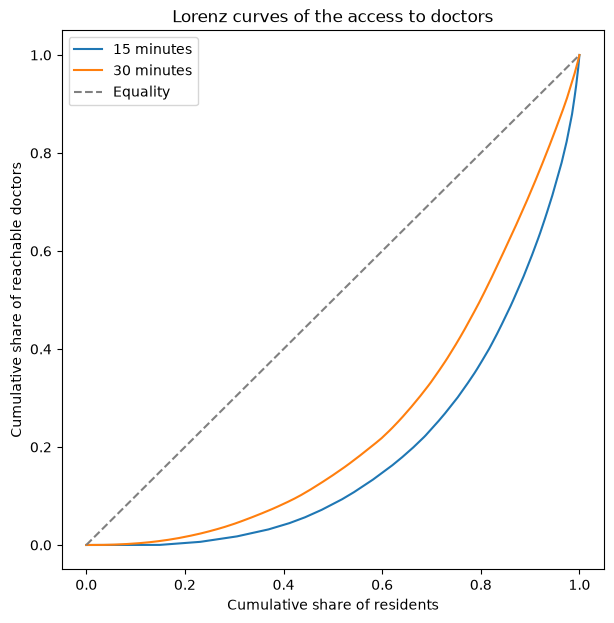

In [15]:
# Calculate the Lorenz curves
lorenz = access.lorenz_curve(sociodemographic_data=census_data, population="population")

# Select the curves of the access to doctors
lorenz_doctors = lorenz.loc[lorenz["opportunity"] == "doctors"]
lorenz_15 = lorenz_doctors.loc[lorenz_doctors["budget"] == 15]
lorenz_30 = lorenz_doctors.loc[lorenz_doctors["budget"] == 30]

# Plot the curves and the line of equality
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(lorenz_15["population_share"], lorenz_15["value_share"], label="15 minutes")
ax.plot(lorenz_30["population_share"], lorenz_30["value_share"], label="30 minutes")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Equality")

# Add labels, title and legend
ax.set_xlabel("Cumulative share of residents")
ax.set_ylabel("Cumulative share of reachable doctors")
ax.set_title("Lorenz curves of the access to doctors")
ax.legend();

The curves bend far from the diagonal. Within 15 minutes, the half of the residents with the poorest access hold only 8 % of the total access to doctors, while the 20 % with the best access hold 63 % of it. Within 30 minutes, the curve moves closer to the diagonal, but the half with the poorest access still hold only 14 %.

### Do children and older residents have the same access?

With the `population` parameter, we can also weight the squares by the number of children or older residents. Then the Gini index describes the distribution of access among that group:

In [16]:
# Gini index weighted by the number of children
gini_children = access.gini_index(sociodemographic_data=census_data, population="children")

# Gini index weighted by the number of older residents
gini_older = access.gini_index(sociodemographic_data=census_data, population="older")

# Combine the results into one table
gini_groups = gini[["opportunity", "budget"]].copy()
gini_groups["all residents"] = gini["gini_index"]
gini_groups["children"] = gini_children["gini_index"]
gini_groups["older residents"] = gini_older["gini_index"]

gini_groups.round(3)

,opportunity,budget,all residents,children,older residents
0,doctors,15.0,0.617,0.629,0.611
1,doctors,30.0,0.493,0.511,0.504
2,pharmacy,15.0,0.615,0.618,0.606
3,pharmacy,30.0,0.500,0.519,0.515
4,school,15.0,0.559,0.565,0.557
5,school,30.0,0.497,0.511,0.506
6,supermarket,15.0,0.545,0.552,0.544
7,supermarket,30.0,0.482,0.497,0.495


The differences between the groups are small, but the access of children is more unequal than that of all residents for every service and budget. Children live more often in the squares with poor access: in the squares from which at least two of the four services cannot be reached within 15 minutes, 18.5 % of the residents are children, compared with 16.0 % in the other squares. The Gini indices of older residents are close to those of all residents.

## Who falls below a minimum level of access?

The Gini index tells how unequal the access is, but not whether the access is good enough: even with a perfectly equal distribution, everyone could lack access to the services they need. To study this **sufficiency** of access, we need to set a **minimum standard**: the level of access that everyone should reach, e.g. "at least one pharmacy within 15 minutes by public transport". Borrowing the terms of poverty research, we call this minimum the **poverty line**, and the residents below it **deprived**. The line is an analytical choice, so always report it together with the results.

For each resident, we can then measure how far below the line they are. The **gap** is the part of the minimum that a resident lacks, as a share of the line:

$$\text{gap} = \frac{\text{line} - \text{accessibility}}{\text{line}}$$

For example, with a line of five supermarkets, a resident who reaches four supermarkets has a gap of (5 − 4) / 5 = 0.2, and a resident who reaches none has a gap of (5 − 0) / 5 = 1. Residents at or above the line have no gap (0).

The **Foster–Greer–Thorbecke (FGT)** measures summarize the gaps of all residents into one number: each deprived resident counts as their gap raised to the power $\alpha$ (*alpha*), each resident at or above the line counts as 0, and the FGT measure is the average over all residents.

The parameter $\alpha$ is chosen by the analyst. It does not change who counts as deprived (the poverty line decides that); it changes how much the depth of each shortfall counts when the deprived residents are summed into one number:

- $\alpha = 0$, the **headcount ratio**: every deprived resident counts as 1, so you get the share below the line. How far below someone is does not matter.
- $\alpha = 1$, the **poverty gap**: the average shortfall. Someone far below the line counts more than someone just below it.
- $\alpha = 2$, the **squared gap** or **severity**: large gaps count disproportionately more, so the measure becomes sensitive to inequality among the deprived residents.

All three range from 0 (nobody is below the line) to 1 (nobody reaches anything). Let's see how they work with four residents and a line of five supermarkets:

| Resident | Supermarkets | Gap | α = 0 | α = 1 | α = 2 |
|---|---|---|---|---|---|
| A | 0 | (5 − 0) / 5 = 1.0 | 1 | 1.0 | 1.0 |
| B | 2 | (5 − 2) / 5 = 0.6 | 1 | 0.6 | 0.36 |
| C | 4 | (5 − 4) / 5 = 0.2 | 1 | 0.2 | 0.04 |
| D | 7 | 0 (above the line) | 0 | 0 | 0 |
| **Average (FGT)** | | | **0.75** | **0.45** | **0.35** |

Three of the four residents are below the line, so the headcount is 0.75. The poverty gap of 0.45 means that, averaged over all four residents, they lack 45 % of the minimum, and the three deprived residents lack on average 0.45 / 0.75 = 60 % of it. The severity of 0.35 comes mostly from resident A, who reaches no supermarket at all: A contributes 1.0 of the total of 1.4, while C, who is only one supermarket short, contributes only 0.04.

In `cafein`, the averages are weighted by the number of residents of each grid square (the `population` parameter), so they are averages over residents, not over squares. Let's set the line at five places of each service within 15 minutes, i.e. a choice between several supermarkets, pharmacies, doctors and schools, and calculate the three measures for all residents:

In [17]:
# Minimum standard: at least five places of the service
minimum = 5

# Calculate the three FGT measures for each service and budget, weighted by the number of residents
headcount = access.fgt_poverty(poverty_line=minimum, alpha=0, deprived="below", sociodemographic_data=census_data, population="population")
poverty_gap = access.fgt_poverty(poverty_line=minimum, alpha=1, deprived="below", sociodemographic_data=census_data, population="population")
severity = access.fgt_poverty(poverty_line=minimum, alpha=2, deprived="below", sociodemographic_data=census_data, population="population")

# Combine the results into one table
fgt = headcount[["opportunity", "budget"]].copy()
fgt["headcount (alpha=0)"] = headcount["fgt_poverty"]
fgt["poverty gap (alpha=1)"] = poverty_gap["fgt_poverty"]
fgt["severity (alpha=2)"] = severity["fgt_poverty"]

# Average gap of the deprived residents
fgt["average gap of the deprived"] = fgt["poverty gap (alpha=1)"] / fgt["headcount (alpha=0)"]

# Show the results of the 15-minute budget
fgt.loc[fgt["budget"] == 15].round(3)

,opportunity,budget,headcount (alpha=0),poverty gap (alpha=1),severity (alpha=2),average gap of the deprived
0,doctors,15.0,0.409,0.291,0.238,0.713
2,pharmacy,15.0,0.698,0.468,0.368,0.670
4,school,15.0,0.679,0.469,0.369,0.691
6,supermarket,15.0,0.466,0.308,0.238,0.661


The **headcount** tells that, with a line of five places within 15 minutes, 41 % of the residents cannot choose between five doctors and 47 % not between five supermarkets, while about 70 % reach fewer than five pharmacies or schools.

The **poverty gap** adds how far below the line the residents are. For doctors, it is 0.29: averaged over all residents, 29 % of the minimum is missing. Dividing it by the headcount gives the **average gap of the deprived**: the residents below the line lack on average 66–71 % of the minimum, i.e. they typically reach only one or two of the five places.

The **severity** is only a little smaller than the poverty gap (e.g. 0.24 vs 0.29 for doctors). If most deprived residents were just short of the line, squaring their small gaps would make the severity much smaller than the poverty gap. Here, many of them reach no place at all: e.g. 15 % of all residents reach no doctor within 15 minutes (as we will see below), more than a third of the 41 % below the line.

Doctors and supermarkets show why we need more than one measure. More residents fall below the line for supermarkets (47 % vs 41 %), but those below the line for doctors are further below it (an average gap of 0.71 vs 0.66), so the severity is the same, 0.24, for both.

### Do children and older residents fall below the line more often?

Finally, let's compare the groups with the lowest possible line: at least one place of the service (`poverty_line=1`). With this line, every deprived resident reaches no place at all, so every gap is 1 and the three FGT measures give the same value: the share of residents who cannot reach any place of the service. We therefore calculate only the headcount (`alpha=0`, the default) for all residents, children and older residents:

In [18]:
# Share of all residents who reach no place of the service
poverty_all = access.fgt_poverty(poverty_line=1, deprived="below", sociodemographic_data=census_data, population="population")

# Share of children who reach no place of the service
poverty_children = access.fgt_poverty(poverty_line=1, deprived="below", sociodemographic_data=census_data, population="children")

# Share of older residents who reach no place of the service
poverty_older = access.fgt_poverty(poverty_line=1, deprived="below", sociodemographic_data=census_data, population="older")

# Combine the results into one table
poverty = poverty_all[["opportunity", "budget"]].copy()
poverty["all residents"] = poverty_all["fgt_poverty"]
poverty["children"] = poverty_children["fgt_poverty"]
poverty["older residents"] = poverty_older["fgt_poverty"]

poverty.round(3)

,opportunity,budget,all residents,children,older residents
0,doctors,15.0,0.146,0.164,0.149
1,doctors,30.0,0.015,0.018,0.013
2,pharmacy,15.0,0.200,0.223,0.205
3,pharmacy,30.0,0.017,0.021,0.015
4,school,15.0,0.195,0.214,0.203
5,school,30.0,0.014,0.016,0.013
6,supermarket,15.0,0.130,0.148,0.138
7,supermarket,30.0,0.012,0.014,0.012


Within 15 minutes, 13 % of the residents cannot reach any supermarket, 15 % any doctor, and about 20 % any pharmacy or school. Within 30 minutes, the shares fall to 1–2 %, so the choice of the budget matters a lot. For every service and budget, the share is larger among children than among all residents: e.g. 22 % of the children cannot reach a pharmacy within 15 minutes, compared with 20 % of all residents. Older residents are close to the average.

Let's map where the residents without a pharmacy within 15 minutes live:

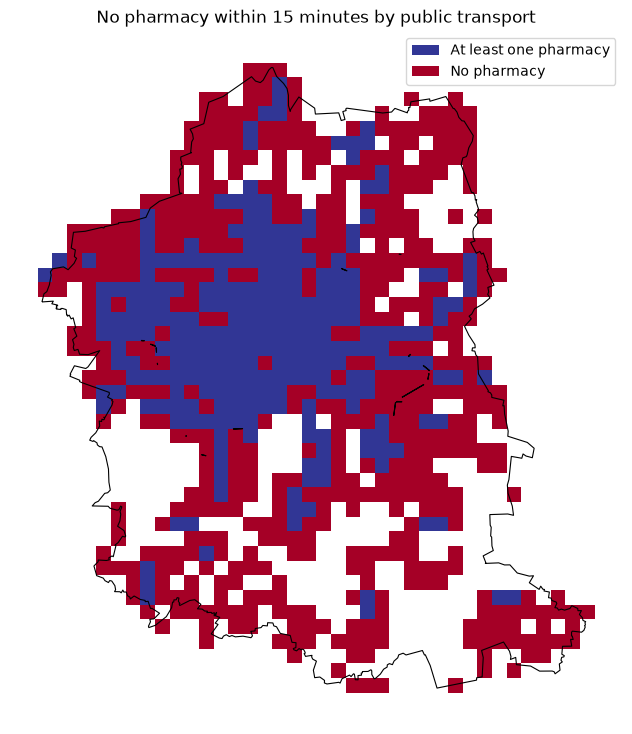

In [19]:
# Select the access to pharmacies within 15 minutes
pharmacy_15 = access.loc[(access["opportunity"] == "pharmacy") & (access["budget"] == 15)]

# Join the results to the grid squares
cells_pharmacy = cells.merge(pharmacy_15, left_on="id", right_on="from_id")

# Label the squares by whether a pharmacy can be reached within 15 minutes
cells_pharmacy["pharmacy_access"] = "At least one pharmacy"
cells_pharmacy.loc[cells_pharmacy["accessibility"] < 1, "pharmacy_access"] = "No pharmacy"

# Plot the squares, those without a pharmacy in red
ax = cells_pharmacy.plot(column="pharmacy_access", cmap="RdYlBu_r", categorical=True, legend=True, figsize=(10, 9))
study_area.boundary.plot(ax=ax, color="black", linewidth=0.8)

# Add title and remove axis
ax.set_title("No pharmacy within 15 minutes by public transport")
ax.set_axis_off();

As we can see, the residents without a pharmacy within 15 minutes live mainly at the edges of the city and in the Landkreis, where the stops are further apart and the services more scattered. The white areas have no residents in the census data.

## Is access concentrated in the more expensive areas?

So far, we have ranked the residents by their accessibility. **Concentration measures** rank them by a socio-economic variable instead, typically income, and ask whether accessibility is concentrated among the residents at the top or at the bottom of that ranking. The census does not include income, so we use the average rent of each grid square as an indicator of how expensive the area is to live in.

The **concentration index** is positive when the access is concentrated in the squares with higher rents, and negative when it is concentrated in the squares with lower rents. The **Palma ratio** divides the mean accessibility of the residents in the 10 % of the population with the highest rents by that of the 40 % with the lowest rents. We leave out the squares without a rent with `dropna=True`:

In [20]:
# Concentration index, with the residents ranked by the rent of their grid square
concentration = access.concentration_index(sociodemographic_data=census_data, income="rent", population="population", dropna=True)

# Palma ratio: the top 10 % of rents compared with the bottom 40 %
palma = access.palma_ratio(sociodemographic_data=census_data, income="rent", population="population", dropna=True)

# Combine the results into one table
rent_measures = concentration.merge(palma, on=["opportunity", "budget"])

rent_measures.round(3)

,opportunity,budget,concentration_index,palma_ratio
0,doctors,15.0,0.281,4.949
1,doctors,30.0,0.212,2.977
2,pharmacy,15.0,0.312,5.458
3,pharmacy,30.0,0.204,2.923
4,school,15.0,0.175,2.901
5,school,30.0,0.191,2.742
6,supermarket,15.0,0.230,3.669
7,supermarket,30.0,0.194,2.814


All concentration indices are positive, between 0.17 and 0.31: the access to every service is concentrated in the squares with higher rents. The Palma ratios tell the same: within 15 minutes, the residents of the 10 % most expensive squares reach on average three to five and a half times as many places as the residents of the 40 % least expensive squares. The differences are the largest for pharmacies and doctors.

This does not necessarily mean that people with lower incomes have poorer access. In Munich, the rents are highest in and around the city center, where the access is also the best, and the good location is one of the reasons why the rents are high there.

The **concentration curve** shows the same in a figure: it is drawn like the Lorenz curve, but the residents are sorted by the rent instead of their accessibility. A curve below the diagonal means that the residents of the more expensive squares have more than their share of the access:

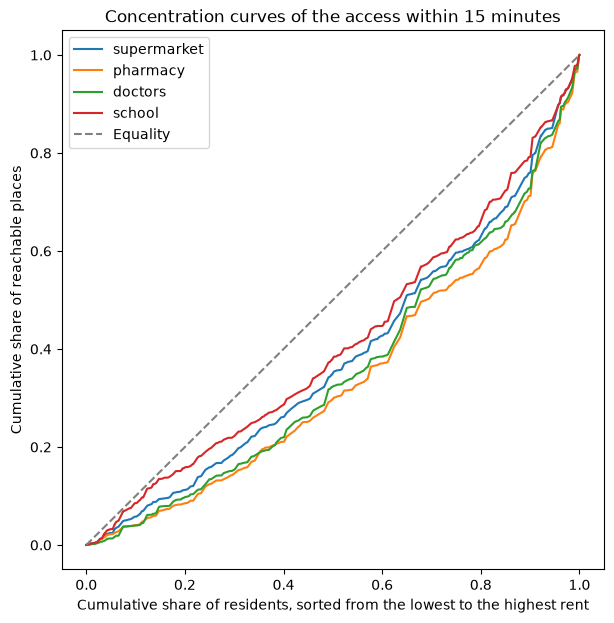

In [21]:
# Calculate the concentration curves
curves = access.concentration_curve(sociodemographic_data=census_data, income="rent", population="population", dropna=True)

# Select the curves of the 15-minute budget
curves_15 = curves.loc[curves["budget"] == 15]

# Plot the curve of each service and the line of equality
fig, ax = plt.subplots(figsize=(7, 7))
for service in services:
    service_curve = curves_15.loc[curves_15["opportunity"] == service]
    ax.plot(service_curve["population_share"], service_curve["value_share"], label=service)
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Equality")

# Add labels, title and legend
ax.set_xlabel("Cumulative share of residents, sorted from the lowest to the highest rent")
ax.set_ylabel("Cumulative share of reachable places")
ax.set_title("Concentration curves of the access within 15 minutes")
ax.legend();

All four curves lie below the diagonal. Within 15 minutes, the half of the residents who live in the least expensive squares hold only 30 % (pharmacies) to 38 % (schools) of the total access. The access to pharmacies is the most concentrated in the expensive areas, and the access to schools the least.

## Where do disadvantages overlap?

A resident who cannot reach a pharmacy may still reach a supermarket, but some residents lack access to several services at once. The **Alkire–Foster** method, developed for measuring multidimensional poverty, counts the dimensions in which each origin is deprived and marks it as **multidimensionally deprived** when the count reaches a cutoff `k`. Here, a square is deprived in a dimension when it reaches no place of the service within 15 minutes, and we use `k=2`, i.e. at least two of the four services are out of reach.

`equity.alkire_foster()` needs one column for each dimension, so let's first reshape the 15-minute results into a wide table with one column per service:

In [22]:
# Select the results of the 15-minute budget
access_15 = access.loc[access["budget"] == 15]

# Reshape them into one row per grid square and one column per service
access_wide = access_15.pivot(index="from_id", columns="opportunity", values="accessibility")
access_wide = access_wide.reset_index()

# Join the census data
access_wide = access_wide.merge(census_data, left_on="from_id", right_on="id")

access_wide.head()

,from_id,doctors,pharmacy,school,supermarket,id,population,children,older,rent
0,CRS3035RES1000mN2757000E4443000,0.0,0.0,0.0,0.0,CRS3035RES1000mN2757000E4443000,9,4.0,0.0,NaN
1,CRS3035RES1000mN2757000E4444000,0.0,0.0,0.0,0.0,CRS3035RES1000mN2757000E4444000,78,10.0,13.0,10.29
2,CRS3035RES1000mN2757000E4445000,0.0,0.0,0.0,0.0,CRS3035RES1000mN2757000E4445000,11,3.0,0.0,12.34
3,CRS3035RES1000mN2757000E4450000,0.0,0.0,0.0,0.0,CRS3035RES1000mN2757000E4450000,3,0.0,3.0,NaN
4,CRS3035RES1000mN2758000E4442000,0.0,0.0,0.0,0.0,CRS3035RES1000mN2758000E4442000,9,4.0,0.0,14.19


In [23]:
# Deprived when no place of the service can be reached (accessibility below 1)
dimensions = {
    "supermarket": ("<", 1),
    "pharmacy": ("<", 1),
    "doctors": ("<", 1),
    "school": ("<", 1),
}

# Multidimensional deprivation of all residents, children and older residents
deprivation_all = equity.alkire_foster(access_wide, dimensions=dimensions, k=2, population="population")
deprivation_children = equity.alkire_foster(access_wide, dimensions=dimensions, k=2, population="children")
deprivation_older = equity.alkire_foster(access_wide, dimensions=dimensions, k=2, population="older")

# Combine the results into one table
deprivation = pd.concat([deprivation_all, deprivation_children, deprivation_older], ignore_index=True)
deprivation.index = ["all residents", "children", "older residents"]

deprivation.round(3)

,m0,headcount,intensity
all residents,0.138,0.184,0.751
children,0.155,0.207,0.751
older residents,0.141,0.188,0.752


The **headcount** tells that 18 % of all residents live in squares from which at least two of the four services are out of reach within 15 minutes. The **intensity** tells that these residents lack on average 75 % of the services, i.e. three of the four. **M0**, the product of the two, combines them into one number. Children are again affected more often (21 %) than all residents, while older residents are close to the average (19 %).

With `detail=True`, `equity.alkire_foster()` returns the deprivations of each origin, which we can map:

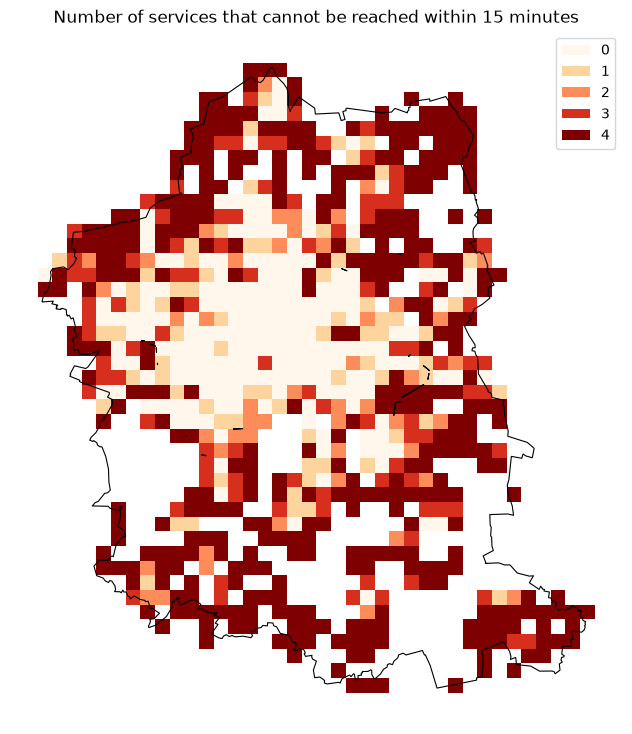

In [24]:
# Deprivations of each grid square
deprivation_detail = equity.alkire_foster(access_wide, dimensions=dimensions, k=2, detail=True)

# Join them to the grid squares
cells_deprivation = cells.merge(deprivation_detail, left_on="id", right_on="from_id")

# Plot the number of services out of reach
ax = cells_deprivation.plot(column="deprivation_count", cmap="OrRd", categorical=True, legend=True, figsize=(10, 9))
study_area.boundary.plot(ax=ax, color="black", linewidth=0.8)

# Add title and remove axis
ax.set_title("Number of services that cannot be reached within 15 minutes")
ax.set_axis_off();

The map shows a clear divide: 70 % of the residents live in squares from which all four services can be reached within 15 minutes, mostly in and around the city center, while 6 % live in squares from which none of them can be reached, mostly at the edges of the region.

## What have we learned?

In this tutorial, we have:

- downloaded census data on a 1 km grid and turned it into a GeoDataFrame of grid squares,
- counted the everyday services that can be reached by public transport from each square with `cafein.Accessibility`,
- measured how unequally access is distributed with the Gini index and Lorenz curves, weighted by the number of residents, children or older residents,
- measured how many residents fall below a minimum standard of access with the FGT measures,
- measured whether access is concentrated in the more expensive areas with the concentration index, the Palma ratio and the concentration curve,
- identified the areas where several services are out of reach with the Alkire–Foster method.

Keep in mind the limitations of the analysis:

- **The grid squares are large.** We route from the center of each 1 km square, so the walking distances of individual residents to the nearest stop can differ a lot from ours.
- **The rent is not income.** It describes the area, not the residents, and it reflects the attractiveness of the location, which includes its accessibility. A high rent can therefore be partly a consequence of good access.
- **One departure time.** Accessibility by public transport changes over the day. With the `departure_time_window` parameter, `cafein` can calculate the results over a time window.
- **The completeness of OpenStreetMap varies.** Some services may be missing or tagged differently in some areas.
- **The minimum standards are choices.** Test how the results change with other budgets, lines and cutoffs.

## Where to go next?

You can continue from here in many directions, e.g. by comparing public transport with cycling, by using a finer grid (the census also publishes a 100 m grid), or by adding environmental dimensions, such as noise or emissions, to the multidimensional analysis. Many of these ideas are also good topics for the [final assignment](../fa/final-assignment.rst).

In case you want to learn more, we recommend reading:

- Willberg, E., Tenkanen, H., Miller, H. J., Pereira, R. H. M. & Toivonen, T. (2024). [Measuring just accessibility within planetary boundaries.](https://doi.org/10.1080/01441647.2023.2240958) *Transport Reviews*, 44(1), 140–166.

*Data: Zensus 2022, © Statistische Ämter des Bundes und der Länder, Data licence Germany – attribution – version 2.0; map data © OpenStreetMap contributors (ODbL); timetables DELFI e.V. (CC BY).*